In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.font_manager import fontManager, FontProperties

df_path = "/Users/royalmustaches/Documents/Programming/Dano/DANO_ITMO_2026/Datasets/DANO_ITMO.csv"
df = pd.read_csv(df_path)

PALETTE = ["#5e17eb", "#ff6b6b", "#00c49a"]
FONT_CANDIDATES = [
    "/Users/royalmustaches/Documents/Programming/Dano/DANO_ITMO_2026/HSE_FONTS_FOR_GRAPHS_copy/HSESlab-Regular.ttf",
    "/Users/royalmustaches/Documents/Programming/Dano/DANO_NES_2026/HSE_FONTS_FOR_GRAPHS/HSESlab-Regular.ttf",
    "/Users/royalmustaches/Documents/Programming/Dano/Practice/Organization/Fonts_for_projects/HSESlab-Regular.ttf",
]

FONT_NAME = "DejaVu Sans"
for font_path in FONT_CANDIDATES:
    if os.path.exists(font_path):
        fontManager.addfont(font_path)
        FONT_NAME = FontProperties(fname=font_path).get_name()
        break

sns.set_theme(style="whitegrid", font=FONT_NAME, context="notebook", palette=PALETTE)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["grid.linestyle"] = "--"

PRIMARY = "#5e17eb"
SECONDARY = "#ff6b6b"
ACCENT = "#00c49a"

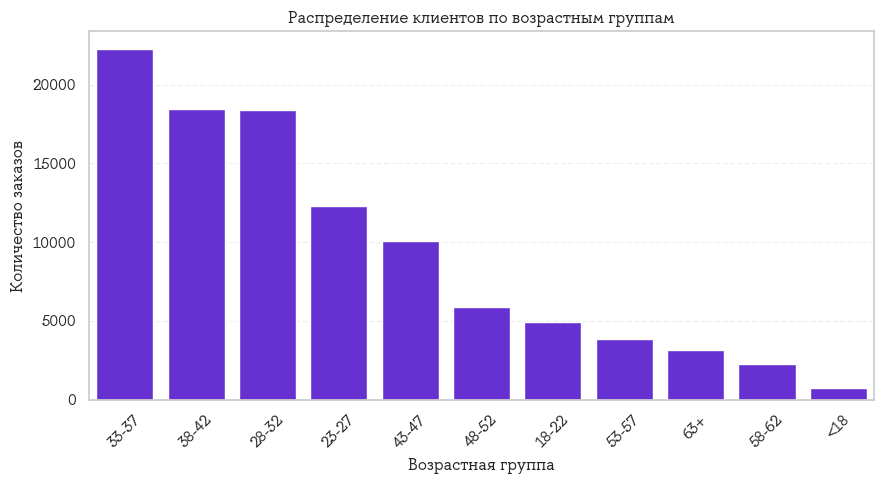

In [8]:
plt.figure(figsize=(9, 5))

order = (
    df['age_group']
    .dropna()
    .value_counts()
    .index
)

sns.countplot(
    data=df,
    x="age_group",
    order=order
)

plt.title("Распределение клиентов по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
import numpy as np

# df = pd.read_csv("Датасет_Дано (1).csv", encoding="utf-8-sig")

excluded_age_groups = ["58-62", "63+", "<18"]

df = (
    df
    # Удаляем NaN в age_group
    .dropna(subset=["age_group"])
    # Удаляем ненужные возрастные группы
    .loc[lambda x: ~x["age_group"].isin(excluded_age_groups)]
    .copy()
)

# Создаем порядок возрастных групп по нижней границе интервала
age_order = (
    df["age_group"]
    .drop_duplicates()
    .sort_values(key=lambda s: pd.to_numeric(s.str.extract(r"(\d+)")[0], errors="coerce"))
    .tolist()
)

# Создаем ранги: самая младшая оставшаяся группа = 0
age_rank_map = {group: rank for rank, group in enumerate(age_order)}

df["age_group_rank"] = df["age_group"].map(age_rank_map)

# Проверка
print(
    df[["age_group", "age_group_rank"]]
    .drop_duplicates()
    .sort_values("age_group_rank")
)

   age_group  age_group_rank
1      18-22               0
21     23-27               1
3      28-32               2
0      33-37               3
4      38-42               4
16     43-47               5
7      48-52               6
23     53-57               7


In [13]:
import numpy as np

df["revenue_to_gmv_markup"] = np.where(
    df["gmv_with_markup"].notna() & (df["gmv_with_markup"] != 0),
    df["revenue"] / df["gmv_with_markup"],
    np.nan
)

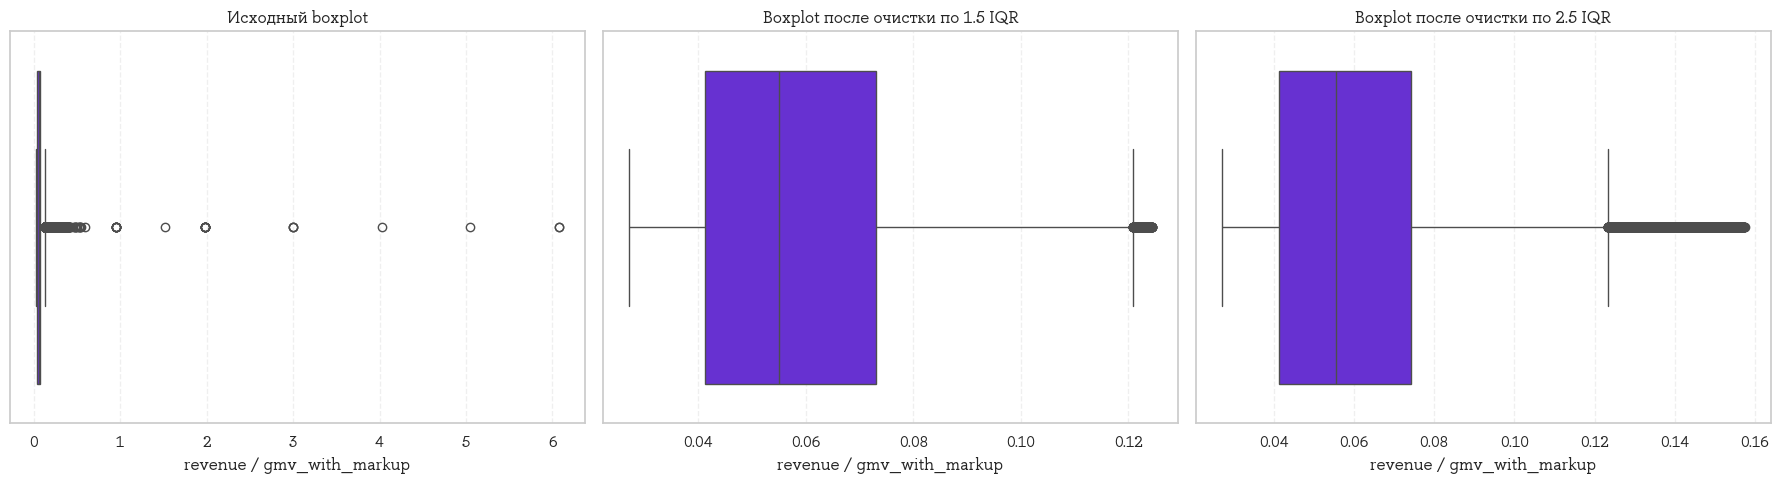

Исходно наблюдений: 96167
После очистки по 1.5 IQR: 94100
После очистки по 2.5 IQR: 95493


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Если колонка еще не создана
df["revenue_to_gmv_markup"] = np.where(
    df["gmv_with_markup"].notna() & (df["gmv_with_markup"] != 0),
    df["revenue"] / df["gmv_with_markup"],
    np.nan
)

# Подготовка исходных данных
plot_data = (
    df["revenue_to_gmv_markup"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# Функция очистки по IQR
def remove_outliers_iqr(series, multiplier):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr

    return series[
        (series >= lower_bound) & 
        (series <= upper_bound)
    ]

# Данные после очистки
plot_data_1_5_iqr = remove_outliers_iqr(plot_data, multiplier=1.5)
plot_data_2_5_iqr = remove_outliers_iqr(plot_data, multiplier=2.5)

# Построение трех boxplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x=plot_data, ax=axes[0])
axes[0].set_title("Исходный boxplot")
axes[0].set_xlabel("revenue / gmv_with_markup")

sns.boxplot(x=plot_data_1_5_iqr, ax=axes[1])
axes[1].set_title("Boxplot после очистки по 1.5 IQR")
axes[1].set_xlabel("revenue / gmv_with_markup")

sns.boxplot(x=plot_data_2_5_iqr, ax=axes[2])
axes[2].set_title("Boxplot после очистки по 2.5 IQR")
axes[2].set_xlabel("revenue / gmv_with_markup")

plt.tight_layout()
plt.show()

# Проверка, сколько наблюдений осталось
print(f"Исходно наблюдений: {len(plot_data)}")
print(f"После очистки по 1.5 IQR: {len(plot_data_1_5_iqr)}")
print(f"После очистки по 2.5 IQR: {len(plot_data_2_5_iqr)}")

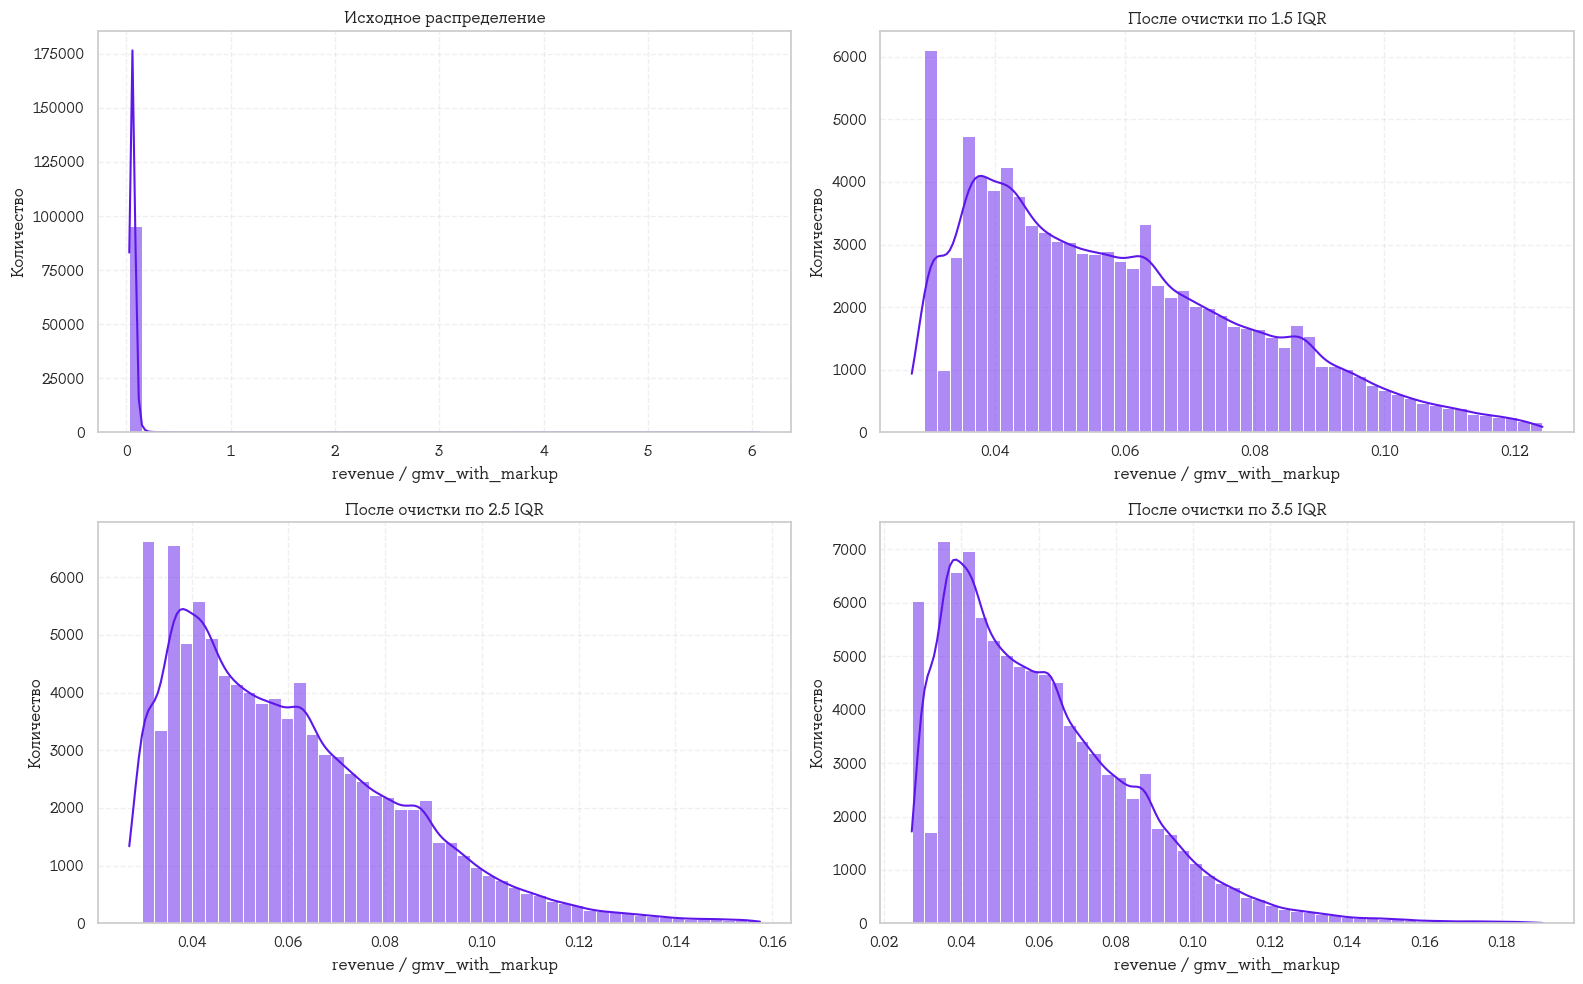

Исходно наблюдений: 96167
После очистки по 1.5 IQR: 94100
После очистки по 2.5 IQR: 95493
После очистки по 3.5 IQR: 95829


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Если колонка еще не создана
df["revenue_to_gmv_markup"] = np.where(
    df["gmv_with_markup"].notna() & (df["gmv_with_markup"] != 0),
    df["revenue"] / df["gmv_with_markup"],
    np.nan
)

# Подготовка исходных данных
plot_data = (
    df["revenue_to_gmv_markup"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# Функция очистки по IQR
def remove_outliers_iqr(series, multiplier):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr

    return series[
        (series >= lower_bound) &
        (series <= upper_bound)
    ]

# Данные после очистки
plot_data_1_5_iqr = remove_outliers_iqr(plot_data, multiplier=1.5)
plot_data_2_5_iqr = remove_outliers_iqr(plot_data, multiplier=2.5)
plot_data_3_5_iqr = remove_outliers_iqr(plot_data, multiplier=3.5)

# Построение 4 графиков распределения
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(plot_data, bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Исходное распределение")
axes[0, 0].set_xlabel("revenue / gmv_with_markup")
axes[0, 0].set_ylabel("Количество")

sns.histplot(plot_data_1_5_iqr, bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("После очистки по 1.5 IQR")
axes[0, 1].set_xlabel("revenue / gmv_with_markup")
axes[0, 1].set_ylabel("Количество")

sns.histplot(plot_data_2_5_iqr, bins=50, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("После очистки по 2.5 IQR")
axes[1, 0].set_xlabel("revenue / gmv_with_markup")
axes[1, 0].set_ylabel("Количество")

sns.histplot(plot_data_3_5_iqr, bins=50, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("После очистки по 3.5 IQR")
axes[1, 1].set_xlabel("revenue / gmv_with_markup")
axes[1, 1].set_ylabel("Количество")

plt.tight_layout()
plt.show()

# Сколько наблюдений осталось
print(f"Исходно наблюдений: {len(plot_data)}")
print(f"После очистки по 1.5 IQR: {len(plot_data_1_5_iqr)}")
print(f"После очистки по 2.5 IQR: {len(plot_data_2_5_iqr)}")
print(f"После очистки по 3.5 IQR: {len(plot_data_3_5_iqr)}")

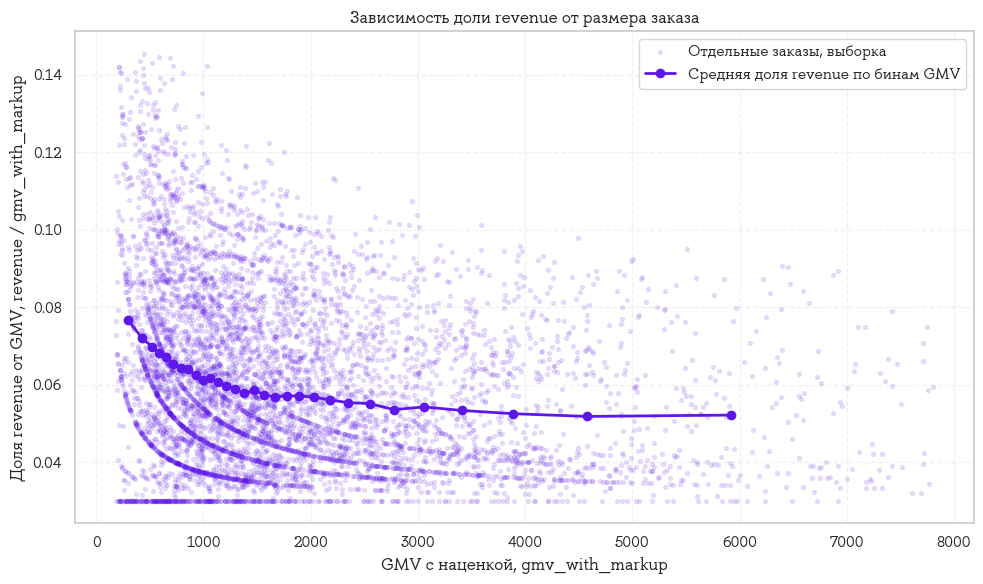

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Если df уже загружен, этот блок не нужен
# df = pd.read_csv('Датасет_Дано (1).csv')

# 1. Создаем долю revenue от GMV
df_plot = df.copy()
df_plot['revenue_share'] = df_plot['revenue'] / df_plot['gmv_with_markup']

# 2. Чистим технически некорректные значения
df_plot = df_plot.replace([np.inf, -np.inf], np.nan)
df_plot = df_plot.dropna(subset=['gmv_with_markup', 'revenue_share'])
df_plot = df_plot[df_plot['gmv_with_markup'] > 0]

# 3. Для читаемости графика убираем крайние 1% выбросов только на визуализации
x_low, x_high = df_plot['gmv_with_markup'].quantile([0.01, 0.99])
y_low, y_high = df_plot['revenue_share'].quantile([0.01, 0.99])

df_vis = df_plot[
    df_plot['gmv_with_markup'].between(x_low, x_high) &
    df_plot['revenue_share'].between(y_low, y_high)
].copy()

# 4. Бинируем GMV, чтобы увидеть устойчивый тренд, а не шум 100k точек
df_vis['gmv_bin'] = pd.qcut(
    df_vis['gmv_with_markup'],
    q=30,
    duplicates='drop'
)

binned = (
    df_vis
    .groupby('gmv_bin', observed=True)
    .agg(
        gmv_mid=('gmv_with_markup', 'median'),
        revenue_share_mean=('revenue_share', 'mean'),
        revenue_share_median=('revenue_share', 'median'),
        n_orders=('revenue_share', 'size')
    )
    .reset_index()
)

# 5. График
plt.figure(figsize=(10, 6))

sample = df_vis.sample(min(7000, len(df_vis)), random_state=42)

plt.scatter(
    sample['gmv_with_markup'],
    sample['revenue_share'],
    alpha=0.12,
    s=8,
    label='Отдельные заказы, выборка'
)

plt.plot(
    binned['gmv_mid'],
    binned['revenue_share_mean'],
    marker='o',
    linewidth=2,
    label='Средняя доля revenue по бинам GMV'
)

plt.xlabel('GMV с наценкой, gmv_with_markup')
plt.ylabel('Доля revenue от GMV, revenue / gmv_with_markup')
plt.title('Зависимость доли revenue от размера заказа')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:          revenue_share   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     1531.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:31:22   Log-Likelihood:             1.6420e+05
No. Observations:              102351   AIC:                        -3.284e+05
Df Residuals:                  102346   BIC:                        -3.283e+05
Df Model:                           4                                         
Covariance Type:              cluster                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0614      0.000    161.643

,term,coef_pp,std_err_pp,z,p_value,ci_low_pp,ci_high_pp
0,Intercept,6.143307,0.038005,161.642741,0.000000e+00,6.068818,6.217797
1,cb_percent,-0.107888,0.003685,-29.281390,1.789936e-188,-0.115110,-0.100667
2,cb_x_markup_1,0.029232,0.003658,7.991230,1.335995e-15,0.022063,0.036402
3,cb_x_markup_5,0.163009,0.004502,36.211151,4.064411e-287,0.154186,0.171832
4,cb_x_markup_9,0.275082,0.003966,69.356107,0.000000e+00,0.267309,0.282856


<Wald test (chi2): statistic=[[6062.59461771]], p-value=0.0, df_denom=3>


,cb_percent,cb_x_markup_1,cb_x_markup_5,cb_x_markup_9
cb_percent,1.000000,0.313196,0.307448,0.290353
cb_x_markup_1,0.313196,1.000000,-0.208806,-0.199668
cb_x_markup_5,0.307448,-0.208806,1.000000,-0.191360
cb_x_markup_9,0.290353,-0.199668,-0.191360,1.000000


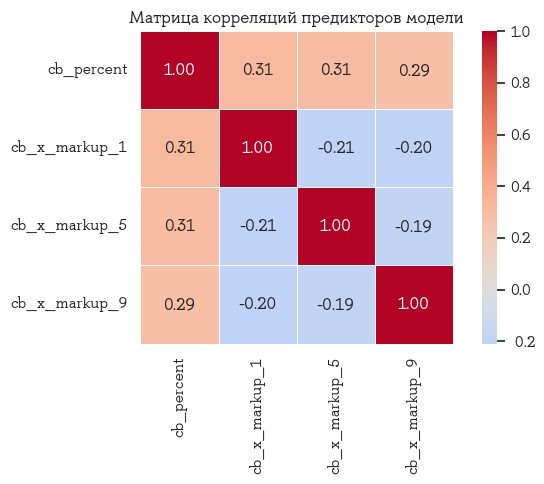

,variable,VIF
1,cb_percent,1.856724
2,cb_x_markup_1,1.612652
3,cb_x_markup_5,1.593383
4,cb_x_markup_9,1.555022


,cb_percent,markup,markup_1,markup_5,markup_9,cb_x_markup_1,cb_x_markup_5,cb_x_markup_9,predicted_revenue_share,ci_low,ci_high,predicted_revenue_share_pp,ci_low_pp,ci_high_pp
0,0.000000,0,0,0,0,0.0,0.0,0.000000,0.061433,0.060688,0.062178,6.143307,6.068818,6.217797
1,0.000000,1,1,0,0,0.0,0.0,0.000000,0.061433,0.060688,0.062178,6.143307,6.068818,6.217797
2,0.000000,5,0,1,0,0.0,0.0,0.000000,0.061433,0.060688,0.062178,6.143307,6.068818,6.217797
3,0.000000,9,0,0,1,0.0,0.0,0.000000,0.061433,0.060688,0.062178,6.143307,6.068818,6.217797
4,0.252525,0,0,0,0,0.0,0.0,0.000000,0.061161,0.060428,0.061893,6.116063,6.042832,6.189294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,24.747475,9,0,0,1,0.0,0.0,24.747475,0.102809,0.101244,0.104375,10.280946,10.124367,10.437526
396,25.000000,0,0,0,0,0.0,0.0,0.000000,0.034461,0.033068,0.035854,3.446106,3.306762,3.585450
397,25.000000,1,1,0,0,25.0,0.0,0.000000,0.041769,0.040364,0.043174,4.176913,4.036419,4.317407
398,25.000000,5,0,1,0,0.0,25.0,0.000000,0.075213,0.073251,0.077175,7.521334,7.325144,7.717524


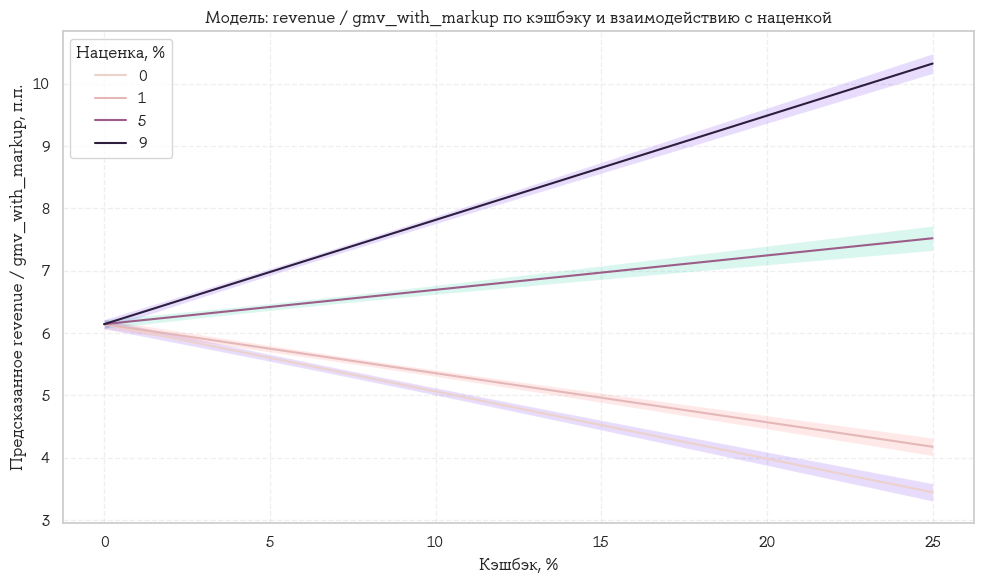

In [8]:
import pandas as pd
import numpy as np

import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# =========================
# 1. Подготовка данных
# =========================

df_model = df.copy()

df_model.columns = (
    df_model.columns
    .str.replace('\ufeff', '', regex=False)
    .str.strip()
)

# Целевая переменная
df_model = df_model[df_model['gmv_with_markup'] > 0].copy()
df_model['revenue_share'] = df_model['revenue'] / df_model['gmv_with_markup']

# Оставляем только нужные наблюдения
df_model = df_model.dropna(
    subset=[
        'revenue_share',
        'markup',
        'cb_percent'
    ]
).copy()

# Оставляем только нужные уровни наценки
df_model = df_model[df_model['markup'].isin([0, 1, 5, 9])].copy()
df_model['markup'] = df_model['markup'].astype(int)

# =========================
# 2. Флаги наценки
# =========================
# ВАЖНО:
# сами флаги markup_1, markup_5, markup_9 НЕ включаем в модель отдельно.
# Они нужны только для взаимодействий с cb_percent.

df_model['markup_1'] = (df_model['markup'] == 1).astype(int)
df_model['markup_5'] = (df_model['markup'] == 5).astype(int)
df_model['markup_9'] = (df_model['markup'] == 9).astype(int)

# =========================
# 3. Взаимодействия cb_percent × markup_flag
# =========================

df_model['cb_x_markup_1'] = df_model['cb_percent'] * df_model['markup_1']
df_model['cb_x_markup_5'] = df_model['cb_percent'] * df_model['markup_5']
df_model['cb_x_markup_9'] = df_model['cb_percent'] * df_model['markup_9']

# =========================
# 4. Линейная регрессия
# =========================

formula = """
revenue_share ~ cb_percent
              + cb_x_markup_1
              + cb_x_markup_5
              + cb_x_markup_9
"""

if 'client_id' in df_model.columns:
    model_cb_only = smf.ols(
        formula=formula,
        data=df_model
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_model['client_id']}
    )
else:
    model_cb_only = smf.ols(
        formula=formula,
        data=df_model
    ).fit(cov_type='HC3')

print(model_cb_only.summary())

# =========================
# 5. Таблица коэффициентов в процентных пунктах
# =========================

coef_table_cb_only = model_cb_only.summary2().tables[1].reset_index()
coef_table_cb_only = coef_table_cb_only.rename(columns={'index': 'term'})

for col in ['Coef.', 'Std.Err.', '[0.025', '0.975]']:
    coef_table_cb_only[col] = coef_table_cb_only[col] * 100

coef_table_cb_only = coef_table_cb_only.rename(columns={
    'Coef.': 'coef_pp',
    'Std.Err.': 'std_err_pp',
    '[0.025': 'ci_low_pp',
    '0.975]': 'ci_high_pp',
    'P>|z|': 'p_value'
})

display(coef_table_cb_only)

# =========================
# 6. Совместный тест взаимодействий
# =========================

print(
    model_cb_only.wald_test(
        'cb_x_markup_1 = 0, cb_x_markup_5 = 0, cb_x_markup_9 = 0'
    )
)

# =========================
# 7. Матрица корреляций предикторов
# =========================

predictors_cb_only = [
    'cb_percent',
    'cb_x_markup_1',
    'cb_x_markup_5',
    'cb_x_markup_9'
]

X_cb_only = df_model[predictors_cb_only].dropna().copy()

corr_matrix_cb_only = X_cb_only.corr()

display(corr_matrix_cb_only)

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr_matrix_cb_only,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Матрица корреляций предикторов модели')
plt.tight_layout()
plt.show()

# =========================
# 8. VIF
# =========================

X_vif_cb_only = sm.add_constant(X_cb_only)

vif_table_cb_only = pd.DataFrame({
    'variable': X_vif_cb_only.columns,
    'VIF': [
        variance_inflation_factor(X_vif_cb_only.values, i)
        for i in range(X_vif_cb_only.shape[1])
    ]
})

vif_table_cb_only = vif_table_cb_only[vif_table_cb_only['variable'] != 'const'].copy()
vif_table_cb_only = vif_table_cb_only.sort_values('VIF', ascending=False)

display(vif_table_cb_only)

# =========================
# 9. Предсказания для графика
# =========================
# Для непрерывного cb_percent строим сетку значений
# от 1-го до 99-го процентиля, чтобы не растягивать график выбросами.

cb_min = df_model['cb_percent'].quantile(0.01)
cb_max = df_model['cb_percent'].quantile(0.99)

cb_grid = np.linspace(cb_min, cb_max, 100)

pred_grid = pd.DataFrame([
    {
        'cb_percent': cb,
        'markup': markup
    }
    for cb in cb_grid
    for markup in [0, 1, 5, 9]
])

pred_grid['markup_1'] = (pred_grid['markup'] == 1).astype(int)
pred_grid['markup_5'] = (pred_grid['markup'] == 5).astype(int)
pred_grid['markup_9'] = (pred_grid['markup'] == 9).astype(int)

pred_grid['cb_x_markup_1'] = pred_grid['cb_percent'] * pred_grid['markup_1']
pred_grid['cb_x_markup_5'] = pred_grid['cb_percent'] * pred_grid['markup_5']
pred_grid['cb_x_markup_9'] = pred_grid['cb_percent'] * pred_grid['markup_9']

pred = model_cb_only.get_prediction(pred_grid).summary_frame(alpha=0.05)

pred_grid['predicted_revenue_share'] = pred['mean']
pred_grid['ci_low'] = pred['mean_ci_lower']
pred_grid['ci_high'] = pred['mean_ci_upper']

pred_grid['predicted_revenue_share_pp'] = pred_grid['predicted_revenue_share'] * 100
pred_grid['ci_low_pp'] = pred_grid['ci_low'] * 100
pred_grid['ci_high_pp'] = pred_grid['ci_high'] * 100

display(pred_grid)

# =========================
# 10. Визуализация модели
# =========================

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=pred_grid,
    x='cb_percent',
    y='predicted_revenue_share_pp',
    hue='markup'
)

for markup_value in [0, 1, 5, 9]:
    temp = pred_grid[pred_grid['markup'] == markup_value]

    plt.fill_between(
        temp['cb_percent'],
        temp['ci_low_pp'],
        temp['ci_high_pp'],
        alpha=0.15
    )

plt.title('Модель: revenue / gmv_with_markup по кэшбэку и взаимодействию с наценкой')
plt.xlabel('Кэшбэк, %')
plt.ylabel('Предсказанное revenue / gmv_with_markup, п.п.')
plt.legend(title='Наценка, %')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()